# ReservoirClassifier on MNIST and Fashion-MNIST

This notebook benchmarks `merlin.models.ReservoirClassifier` on MNIST and Fashion-MNIST with the current built-in API.

Requested experiment grid:

- `3` photons with `12` PCA components
- `3` photons with `16` PCA components

The photonic reservoir is frozen after `fit_reservoir()`. Only the linear readout is trained.

The first execution downloads the datasets through Merlin's dataset loaders. Full MNIST-sized runs can be slow for a photonic reservoir, so the notebook uses configurable stratified subsets by default.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import perceval as pcvl
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

from merlin import MerlinProcessor
from merlin.datasets import fashion_mnist, mnist_digits
from merlin.models import ReservoirClassifier

In [2]:
SEED = 7
TRAIN_SAMPLES = 60000
TEST_SAMPLES = 10000
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 1e-3
DEVICE = torch.device("cpu")

EXPERIMENTS = [
    {"n_photons": 3, "n_components": 12},
    {"n_photons": 3, "n_components": 16},
]


def set_seed(seed: int = SEED) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed()
print(
    f"train_samples={TRAIN_SAMPLES}, test_samples={TEST_SAMPLES}, "
    f"epochs={EPOCHS}, batch_size={BATCH_SIZE}"
)

train_samples=60000, test_samples=10000, epochs=100, batch_size=128


In [3]:
DATASET_LOADERS = {
    "MNIST": (
        mnist_digits.get_data_train_original,
        mnist_digits.get_data_test_original,
    ),
    "Fashion-MNIST": (
        fashion_mnist.get_data_train,
        fashion_mnist.get_data_test,
    ),
}


def stratified_subset(X, y, n_samples, seed):
    if n_samples is None or n_samples >= len(X):
        return X, y
    X_sub, _, y_sub, _ = train_test_split(
        X,
        y,
        train_size=n_samples,
        stratify=y,
        random_state=seed,
    )
    return X_sub, y_sub


def subset_per_class(X, y, n_samples_per_class, seed):
    if n_samples_per_class is None:
        return X, y

    rng = np.random.default_rng(seed)
    selected_indices = []
    for class_label in np.unique(y):
        class_indices = np.flatnonzero(y == class_label)
        if n_samples_per_class > len(class_indices):
            raise ValueError(
                f"Requested {n_samples_per_class} samples for class {class_label}, "
                f"but only {len(class_indices)} are available."
            )
        selected_indices.append(
            rng.choice(class_indices, size=n_samples_per_class, replace=False)
        )

    selected_indices = np.concatenate(selected_indices)
    rng.shuffle(selected_indices)
    return X[selected_indices], y[selected_indices]


def load_dataset(
    name,
    train_samples=TRAIN_SAMPLES,
    test_samples=TEST_SAMPLES,
    train_samples_per_class=None,
    test_samples_per_class=None,
    seed=SEED,
):
    if train_samples is not None and train_samples_per_class is not None:
        raise ValueError("Use either train_samples or train_samples_per_class, not both.")
    if test_samples is not None and test_samples_per_class is not None:
        raise ValueError("Use either test_samples or test_samples_per_class, not both.")

    train_loader, test_loader = DATASET_LOADERS[name]
    X_train, y_train, _ = train_loader()
    X_test, y_test, _ = test_loader()
    print(f"Orignal {name}: train={X_train.shape}, test={X_test.shape}, classes={len(np.unique(y_train))}")

    X_train = X_train.reshape(len(X_train), -1).astype(np.float32) / 255.0
    X_test = X_test.reshape(len(X_test), -1).astype(np.float32) / 255.0
    y_train = np.asarray(y_train, dtype=np.int64)
    y_test = np.asarray(y_test, dtype=np.int64)

    if train_samples_per_class is not None:
        X_train, y_train = subset_per_class(
            X_train,
            y_train,
            train_samples_per_class,
            seed,
        )
    else:
        X_train, y_train = stratified_subset(X_train, y_train, train_samples, seed)

    if test_samples_per_class is not None:
        X_test, y_test = subset_per_class(
            X_test,
            y_test,
            test_samples_per_class,
            seed + 1,
        )
    else:
        X_test, y_test = stratified_subset(X_test, y_test, test_samples, seed)

    return X_train, y_train, X_test, y_test


for dataset_name in DATASET_LOADERS:
    X_train, y_train, X_test, y_test = load_dataset(dataset_name)
    print(
        f"{dataset_name}: train={X_train.shape}, test={X_test.shape}, "
        f"classes={len(np.unique(y_train))}"
    )

Extracting train-images-idx3-ubyte_240b3102.gz...
Extracting train-labels-idx1-ubyte_75c0d692.gz...
Extracting t10k-images-idx3-ubyte_7439da10.gz...
Extracting t10k-labels-idx1-ubyte_e0ca9fe5.gz...
Orignal MNIST: train=(60000, 28, 28), test=(10000, 28, 28), classes=10
MNIST: train=(60000, 784), test=(10000, 784), classes=10
Extracting train-images-idx3-ubyte_4748c1d1.gz...
Extracting train-labels-idx1-ubyte_d7a14529.gz...
Extracting t10k-images-idx3-ubyte_b8b23cdc.gz...
Extracting t10k-labels-idx1-ubyte_e182e2ad.gz...
Orignal Fashion-MNIST: train=(60000, 28, 28), test=(10000, 28, 28), classes=10
Fashion-MNIST: train=(60000, 784), test=(10000, 784), classes=10


## Training Helpers

`fit_reservoir()` computes the frozen quantum features. The training loop below only optimizes the linear readout parameters returned by `model.parameters()`.

In [4]:
def train_readout(model, dataset, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0

        for features, targets in loader:
            features = features.to(model.device, dtype=model.dtype)
            targets = targets.to(model.device)

            optimizer.zero_grad()
            logits = model(features)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * targets.shape[0]
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_examples += targets.shape[0]

        history.append(
            {
                "epoch": epoch,
                "loss": total_loss / total_examples,
                "train_accuracy": total_correct / total_examples,
            }
        )

    return pd.DataFrame(history)


def accuracy_with_predictions(logits, y_true):
    predictions = logits.argmax(dim=1).numpy()
    accuracy = accuracy_score(y_true, predictions)
    return accuracy, predictions


def run_experiment(
    dataset_name,
    n_components,
    n_photons=3,
    seed=SEED,
    processor=None,
    train_samples=None,
    test_samples=None,
    train_samples_per_class=None,
    test_samples_per_class=None,
):
    set_seed(seed)
    X_train, y_train, X_test, y_test = load_dataset(
        dataset_name,
        train_samples=(
            None
            if train_samples_per_class is not None
            else (TRAIN_SAMPLES if train_samples is None else train_samples)
        ),
        test_samples=(
            None
            if test_samples_per_class is not None
            else (TEST_SAMPLES if test_samples is None else test_samples)
        ),
        train_samples_per_class=train_samples_per_class,
        test_samples_per_class=test_samples_per_class,
        seed=seed,
    )

    model = ReservoirClassifier(
        in_features=X_train.shape[1],
        out_features=len(np.unique(y_train)),
        n_photons=n_photons,
        reduction=PCA(
            n_components=n_components,
            svd_solver="randomized",
            random_state=seed,
        ),
        concatenate=True,
        cache=True,
        seed=seed,
        device=DEVICE,
        dtype=torch.float32,
    )

    start = time.perf_counter()
    model.fit_reservoir(X_train, processor=processor)
    train_dataset = model.make_dataset(X_train, y_train, processor=processor)
    history = train_readout(model, train_dataset)
    elapsed = time.perf_counter() - start

    train_logits = model.predict(X_train, processor=processor)
    test_logits = model.predict(X_test, processor=processor)
    train_accuracy, train_predictions = accuracy_with_predictions(train_logits, y_train)
    test_accuracy, test_predictions = accuracy_with_predictions(test_logits, y_test)

    result = {
        "run_name": f"{dataset_name} | photons={n_photons} | pca={n_components}",
        "dataset": dataset_name,
        "n_photons": n_photons,
        "n_components": n_components,
        "train_samples": len(X_train),
        "test_samples": len(X_test),
        "train_samples_per_class": train_samples_per_class,
        "test_samples_per_class": test_samples_per_class,
        "quantum_output_size": model.layer.output_size,
        "readout_in_features": model.readout.in_features,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "runtime_seconds": elapsed,
    }

    artifact = {
        "model": model,
        "history": history,
        "X_test": X_test,
        "y_test": y_test,
        "train_predictions": train_predictions,
        "test_predictions": test_predictions,
    }
    return result, artifact

In [23]:
results = []
artifacts = {}

for dataset_name in DATASET_LOADERS:
    for config in EXPERIMENTS:
        run_name = (
            f"{dataset_name} | photons={config['n_photons']} | "
            f"pca={config['n_components']}"
        )
        print(f"Running {run_name}")
        result, artifact = run_experiment(
            dataset_name=dataset_name,
            n_components=config["n_components"],
            n_photons=config["n_photons"],
        )
        results.append(result)
        artifacts[result["run_name"]] = artifact

results_df = pd.DataFrame(results).sort_values(["dataset", "n_components"])
results_df

Running MNIST | photons=3 | pca=12
Orignal MNIST: train=(60000, 28, 28), test=(10000, 28, 28), classes=10
Running MNIST | photons=3 | pca=16
Orignal MNIST: train=(60000, 28, 28), test=(10000, 28, 28), classes=10
Running Fashion-MNIST | photons=3 | pca=12
Orignal Fashion-MNIST: train=(60000, 28, 28), test=(10000, 28, 28), classes=10
Running Fashion-MNIST | photons=3 | pca=16
Orignal Fashion-MNIST: train=(60000, 28, 28), test=(10000, 28, 28), classes=10


,run_name,dataset,n_photons,n_components,train_samples,test_samples,quantum_output_size,readout_in_features,train_accuracy,test_accuracy,runtime_seconds
2,Fashion-MNIST | photons=3 | pca=12,Fashion-MNIST,3,12,60000,10000,220,1004,0.891133,0.8560,37.647071
3,Fashion-MNIST | photons=3 | pca=16,Fashion-MNIST,3,16,60000,10000,560,1344,0.892700,0.8582,54.726170
0,MNIST | photons=3 | pca=12,MNIST,3,12,60000,10000,220,1004,0.969533,0.9569,32.820001
1,MNIST | photons=3 | pca=16,MNIST,3,16,60000,10000,560,1344,0.974833,0.9619,35.766434


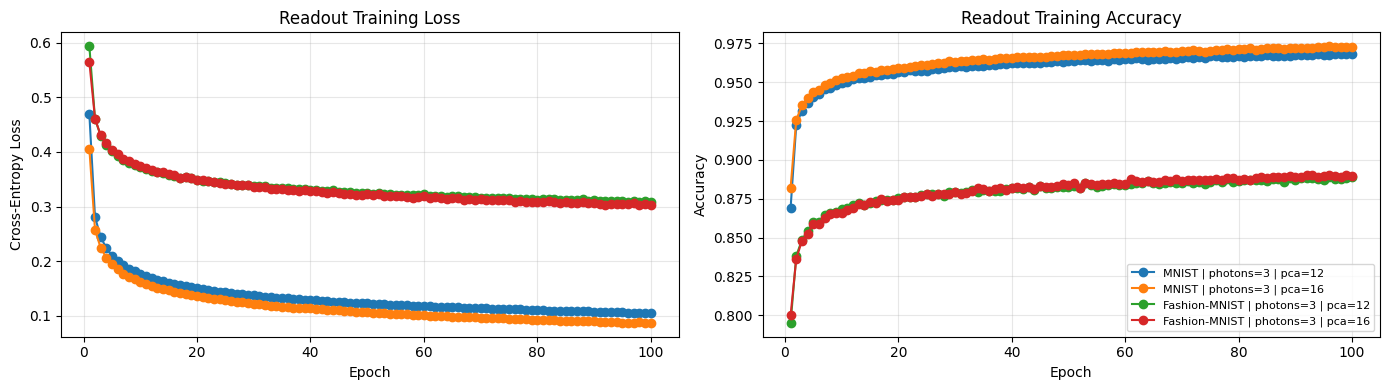

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for run_name, artifact in artifacts.items():
    history = artifact["history"]
    axes[0].plot(history["epoch"], history["loss"], marker="o", label=run_name)
    axes[1].plot(
        history["epoch"],
        history["train_accuracy"],
        marker="o",
        label=run_name,
    )

axes[0].set_title("Readout Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(alpha=0.3)

axes[1].set_title("Readout Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, loc="lower right", fontsize=8)
plt.tight_layout()

,dataset,n_photons,n_components,quantum_output_size,train_accuracy,test_accuracy,runtime_seconds
2,Fashion-MNIST,3,12,220,0.891133,0.8560,37.647071
3,Fashion-MNIST,3,16,560,0.892700,0.8582,54.726170
0,MNIST,3,12,220,0.969533,0.9569,32.820001
1,MNIST,3,16,560,0.974833,0.9619,35.766434


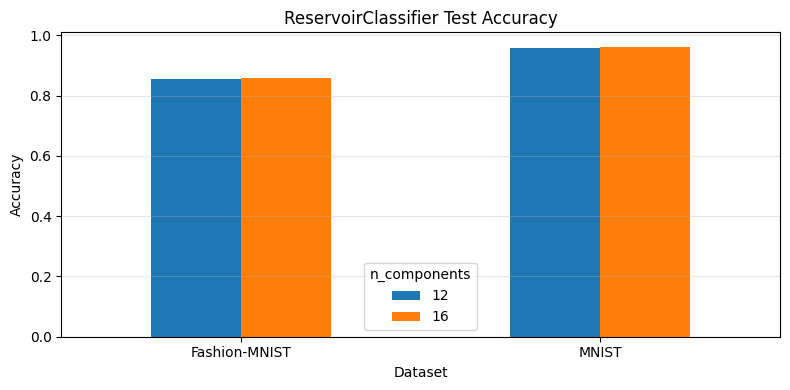

In [25]:
summary = results_df[[
    "dataset",
    "n_photons",
    "n_components",
    "quantum_output_size",
    "train_accuracy",
    "test_accuracy",
    "runtime_seconds",
]].copy()
display(summary)

pivot = results_df.pivot(index="dataset", columns="n_components", values="test_accuracy")
ax = pivot.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("ReservoirClassifier Test Accuracy")
ax.set_xlabel("Dataset")
ax.set_ylabel("Accuracy")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

run_name           MNIST | photons=3 | pca=16
test_accuracy                          0.9619
runtime_seconds                     35.766434
Name: 1, dtype: object
quantum_output_size=560, readout_in_features=1344


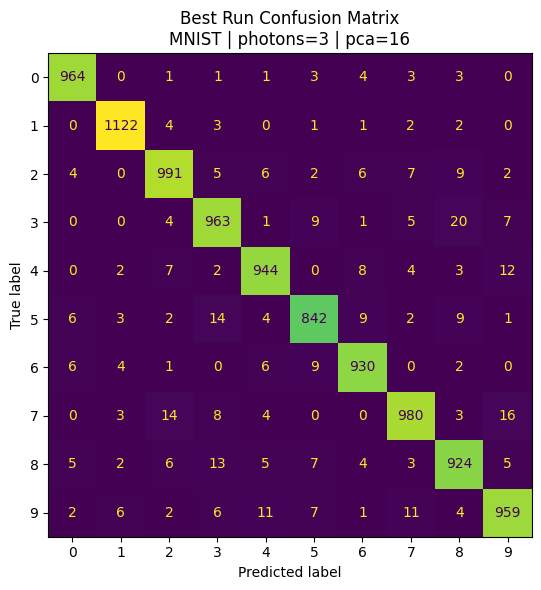

In [26]:
best_row = results_df.sort_values("test_accuracy", ascending=False).iloc[0]
best_run_name = best_row["run_name"]
best_artifact = artifacts[best_run_name]

print(best_row[["run_name", "test_accuracy", "runtime_seconds"]])
print(
    f"quantum_output_size={best_row['quantum_output_size']}, "
    f"readout_in_features={best_row['readout_in_features']}"
)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    best_artifact["y_test"],
    best_artifact["test_predictions"],
    ax=ax,
    colorbar=False,
)
ax.set_title(f"Best Run Confusion Matrix\n{best_run_name}")
plt.tight_layout()

## Part 2: Cloud Processing

The same `ReservoirClassifier` pipeline can offload the frozen quantum reservoir to Quandela Cloud through `MerlinProcessor`.

Only the quantum feature extraction is remote. The linear readout still trains locally in PyTorch.

Paste your token in the next cell or load it from `token_utils.py` if you prefer.

In [5]:
# Option 1: paste your Quandela Cloud token directly.
#CLOUD_TOKEN = ""  # TODO: replace with your token

# Option 2: load it from token_utils.py or your environment.
from token_utils import load_cloud_token
CLOUD_TOKEN = load_cloud_token()

#CLOUD_PLATFORM = "sim:slos"  # exact probabilities on Quandela Cloud
CLOUD_PLATFORM = "sim:ascella"  # example QPU-like simulator

CLOUD_MICROBATCH_SIZE = 32
CLOUD_TIMEOUT = 3600.0
CLOUD_MAX_SHOTS_PER_CALL = None
CLOUD_CHUNK_CONCURRENCY = 1

In [6]:
def build_cloud_processor(
    cloud_token,
    platform=CLOUD_PLATFORM,
    microbatch_size=CLOUD_MICROBATCH_SIZE,
    timeout=CLOUD_TIMEOUT,
    max_shots_per_call=CLOUD_MAX_SHOTS_PER_CALL,
    chunk_concurrency=CLOUD_CHUNK_CONCURRENCY,
):
    token = cloud_token.strip()
    if not token:
        raise ValueError("Add your Quandela Cloud token in the previous cell before building the processor.")

    pcvl.RemoteConfig.set_token(token)
    remote_processor = pcvl.RemoteProcessor(platform)
    return MerlinProcessor(
        remote_processor=remote_processor,
        microbatch_size=microbatch_size,
        timeout=timeout,
        max_shots_per_call=max_shots_per_call,
        chunk_concurrency=chunk_concurrency,
    )


cloud_processor = None
if CLOUD_TOKEN.strip():
    cloud_processor = build_cloud_processor(CLOUD_TOKEN)
    print(f"Cloud processor ready on {CLOUD_PLATFORM}")
else:
    print("Add your token above, then re-run this cell to enable cloud execution.")

Cloud processor ready on sim:ascella


### Optional Cloud Experiment

Start with a smaller subset before launching the full four-run sweep remotely. The cloud cells below use `n_train` and `n_test` samples per class rather than one global subset size.

In [7]:
if cloud_processor is None:
    raise RuntimeError("Build the cloud processor first by adding your token and running the previous cell.")

CLOUD_DATASET = "MNIST"
CLOUD_EXPERIMENT = {"n_photons": 3, "n_components": 12}
CLOUD_TRAIN_SAMPLES_PER_CLASS = 5
CLOUD_TEST_SAMPLES_PER_CLASS = 5

cloud_result, cloud_artifact = run_experiment(
    dataset_name=CLOUD_DATASET,
    n_components=CLOUD_EXPERIMENT["n_components"],
    n_photons=CLOUD_EXPERIMENT["n_photons"],
    processor=cloud_processor,
    train_samples_per_class=CLOUD_TRAIN_SAMPLES_PER_CLASS,
    test_samples_per_class=CLOUD_TEST_SAMPLES_PER_CLASS,
)

pd.DataFrame([cloud_result])

Orignal MNIST: train=(60000, 28, 28), test=(10000, 28, 28), classes=10


,run_name,dataset,n_photons,n_components,train_samples,test_samples,train_samples_per_class,test_samples_per_class,quantum_output_size,readout_in_features,train_accuracy,test_accuracy,runtime_seconds
0,MNIST | photons=3 | pca=12,MNIST,3,12,50,50,5,5,220,1004,1.0,0.28,54.414253


In [ ]:
# Optional: run the complete requested grid remotely.
# Increase the sample counts only after you are comfortable with the runtime and cloud cost.

if cloud_processor is None:
    raise RuntimeError("Build the cloud processor first by adding your token and running the previous cell.")

CLOUD_SWEEP_TRAIN_SAMPLES_PER_CLASS = 64
CLOUD_SWEEP_TEST_SAMPLES_PER_CLASS = 32

cloud_results = []
for dataset_name in DATASET_LOADERS:
    for config in EXPERIMENTS:
        print(
            f"Running cloud experiment: {dataset_name} | "
            f"photons={config['n_photons']} | pca={config['n_components']}"
        )
        result, _ = run_experiment(
            dataset_name=dataset_name,
            n_components=config["n_components"],
            n_photons=config["n_photons"],
            processor=cloud_processor,
            train_samples_per_class=CLOUD_SWEEP_TRAIN_SAMPLES_PER_CLASS,
            test_samples_per_class=CLOUD_SWEEP_TEST_SAMPLES_PER_CLASS,
        )
        cloud_results.append(result)

cloud_results_df = pd.DataFrame(cloud_results).sort_values(["dataset", "n_components"])
cloud_results_df

Running cloud experiment: MNIST | photons=3 | pca=12
Orignal MNIST: train=(60000, 28, 28), test=(10000, 28, 28), classes=10


## Notes

- Increase `TRAIN_SAMPLES`, `TEST_SAMPLES`, or `EPOCHS` if you want a stronger benchmark.
- For cloud execution, paste your token in `CLOUD_TOKEN`, build `cloud_processor`, and tune `CLOUD_*_SAMPLES_PER_CLASS` to control the remote subset size per class.
- Set `concatenate=False` inside `run_experiment()` if you want to test a pure quantum-feature readout instead of concatenating raw pixels with the reservoir output.
- `model.layer.output_size` shows how the photonic feature dimension grows with the number of PCA modes and photons.